Goal: Create a deep learning model that is able to take an image of a fish eye and predict its freshness based on three classes - Highly fresh, fresh, not fresh. 

Input: Fisheye image
Output: Freshness classification 
Constraints: Small dataset, different species
Performance Metrics: Accuracy, F1, Confusion matrix

In [9]:
#imports 
import os, glob, random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt




from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models



#Defines
IMG_SIZE = 224
RANDOM_SEED = 42
BATCH = 32
NUM_CLASSES = 3

In [10]:
#Load Data


DATA_ROOT = Path("data/mendeley")

def build_labels(row_path: str):

    parts = row_path.split(" - ") #Path Name follows: Species - freshness\IMG_xxx
    species_raw, freshness_raw = parts #Split folder name to aquire species and freshness
    species = species_raw.strip().lower()
    freshness = freshness_raw.strip().lower()

    if freshness == "highly fresh": #Map freshness to values 0, 1, 2
        label,label_name = 0, "Highly Fresh"
    elif freshness == "fresh":
        label,label_name = 1, "Fresh"
    elif freshness == "not fresh":
        label,label_name = 2, "Not Fresh"

    return species, label, label_name
    
def build_image_labels(root: Path) -> pd.DataFrame: #Create the dataframe to hold our labels and info
    rows = []
    for image_path in root.rglob("*"):

        if not image_path.is_file(): #Ensure it is an image of correct type
            continue
        if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        folder_name = image_path.parent.name
        species, label, label_name = build_labels(folder_name)

        rows.append({
            "path": str(image_path),
            "species": species,
            "label": label,
            "label_name": label_name,
        })

    return pd.DataFrame(rows)
   

df = build_image_labels(DATA_ROOT) #Create DF using all data from mendeley set
display(df)




""


In [7]:
#Check what kinds of augmentation is needed
print("Shape:", df.shape)

#Check for NA - missing values
print("\nMissing values per column:")
print(df.isna().sum())

print("\nLabel counts:")
print(df["label_name"].value_counts())

#Check for class distribution
tab = pd.crosstab(df["label"], df["label_name"])
display(tab)
ax = df["label_name"].value_counts().plot(kind="bar")
ax.set_title("Freshness Class Distribution")
ax.set_xlabel("Class"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

#Freshness vs Species distribution 
ct = pd.crosstab(df["species"], df["label_name"])
display(ct)

ct.plot(kind = "bar", stacked = True)
plt.title("Freshness Distribution per Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.legend(title="Freshness", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Shape: (0, 0)

Missing values per column:
Series([], dtype: float64)

Label counts:


KeyError: 'label_name'

Conclusions:

From Class Distribution:

Classes are relatively balances so heavy class balancing is not needed.

Freshness Vs Species:

Look reasonable spread, but not identical distrubution. Need to amplify smaller deatils of image to ensure lower appearing species are not underrepresented. 

Likely image augmentations: 
Image Size 
Random Image rotation
Random Image flips 


In [3]:
#Train Split Data 70/15/15

train_df, temp_df = train_test_split(df, test_size = 0.3, stratify = df["label"], random_state = RANDOM_SEED)

val_df, test_df = train_test_split(temp_df, test_size = 0.5, stratify = temp_df["label"], random_state = RANDOM_SEED)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["label"].value_counts(normalize=True))



KeyError: 'label'

In [24]:
#Dataset class

class FishFreshnessDS(Dataset):
    def __init__(self, frame, transform):
        self.df = frame.reset_index(drop = True)
        self.transform = transform
        self.paths = self.df["path"].tolist()
        self.labels = self.df["label"].astype(int).tolist()

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        x = self.transform(img) if self.transform else img
        y = torch.tensor(self.labels[i], dtype = torch.long)
        return x, y
    




    


In [25]:
probe_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),            # <- raw [0,1], no Normalize here
])

probe_ds = FishFreshnessDS(train_df, probe_tf)
probe_loader = DataLoader(probe_ds, batch_size=64, shuffle=False, num_workers=0)

n_pixels = 0
sum_c    = torch.zeros(3)
sumsq_c  = torch.zeros(3)

for xb, _ in probe_loader:           # xb: [B,3,H,W] in [0,1]
    B, C, H, W = xb.shape
    n = B*H*W
    n_pixels += n
    sum_c   += xb.sum(dim=[0,2,3])
    sumsq_c += (xb**2).sum(dim=[0,2,3])

mean = sum_c / n_pixels
var  = (sumsq_c / n_pixels) - mean**2
std  = var.clamp_min(1e-12).sqrt()

print("train mean:", mean.tolist())
print("train std :", std.tolist())

IMG_SIZE = 224
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),   # <- use your stats
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

#Create training, validation, and test datasets 
train_ds = FishFreshnessDS(train_df, train_transforms)
val_ds = FishFreshnessDS(val_df, val_transforms)
test_ds = FishFreshnessDS(test_df, val_transforms)


train mean: [0.48181256651878357, 0.4465354084968567, 0.42846518754959106]
train std : [0.1994909793138504, 0.19912664592266083, 0.19779568910598755]


In [26]:
#Dataloaders
train_loader = DataLoader(train_ds, batch_size = BATCH, shuffle = True)
val_loader = DataLoader(val_df, batch_size = BATCH, shuffle = False)
test_loader = DataLoader(test_ds, batch_size= BATCH, shuffle = False)

Fish Freshness Class 

In [ ]:
#Define NN

class FreshnessClass(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv10 = nn.Conv2d(3, 10, kernel_size=3)   # Conv 10
        self.conv5  = nn.Conv2d(10, 5, kernel_size=3)   # Conv 5
        self.conv16 = nn.Conv2d(5, 16, kernel_size=3)   # Conv 16
        
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        
        # Figure out flatten_dim automatically for CIFAR-100 (32x32)
        
        self.dropout = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(400, 256)   # bigger hidden layer
        self.fc2 = nn.Linear(256, 100)           # 100 classes

    def forward(self, x):
        x = self.activation(self.conv10(x))
        x = self.pool(x)
        
        x = self.activation(self.conv5(x))
        
        x = self.activation(self.conv16(x))
        x = self.pool(x)
        
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.activation(self.fc1(x))
        out = self.fc2(x)
        return out

        return x

        


ResNet18 Model

In [ ]:
#Pre Trained Weights
resnet = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)

#Freeze Earlier layers 
for name, param in resnet.named_parameters():
    if not (name.startswith("layer4") or name.startswith("fc")):
        param.requires_grad = False

in_features = resnet.fc.in_features

model = resnet.to(device)

Training with FishFreshness Class

In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- SAFE DATALOADERS (Windows/Jupyter friendly) ---
from torch.utils.data import DataLoader
import torch
from torch import optim, nn

# assumes train_ds, val_ds, test_ds, FreshnessClass, device, EPOCHS, LEARNING_RATE already exist
BATCH = 32  

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=False)

# --- ONE-BATCH PROBE (so we fail fast if anything is off) ---
xb, yb = next(iter(train_loader))
print("probe batch:", xb.shape, yb.shape, yb[:8])

# --- (RE)BUILD MODEL/OPT/LOSS (idempotent) ---
model = FreshnessClass().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

# --- TRAIN / EVAL HELPERS WITH HEARTBEAT ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for b, (xb, yb) in enumerate(loader):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        n += xb.size(0)

        if b % 50 == 0:
            print(f"  batch {b:04d}  loss {loss.item():.4f}", end="\r")
    print()
    return total_loss / max(1, n), correct / max(1, n)

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return total_loss / max(1, n), correct / max(1, n)

# ---------------------------
# 5. Training loop with best checkpoint
# ---------------------------

best_state, best_val_acc = None, 0.0
bad = 0
patience = 20
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = eval_one_epoch(model, val_loader, criterion, device)
    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train {tr_loss:.4f}/{tr_acc:.3f} | "
          f"val {va_loss:.4f}/{va_acc:.3f} | "
          f"lr {optimizer.param_groups[0]['lr']:.3g}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad+=1
        if(bad>= patience):
            print("Early Stopped")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# ---------------------------
# 6. Final test eval
# ---------------------------

test_loss, test_acc = eval_one_epoch(model, test_loader, criterion, device)
print(f"TEST | loss {test_loss:.4f}  acc {test_acc:.3f}")



probe batch: torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor([2, 0, 1, 1, 1, 0, 2, 1])
  batch 0050  loss 1.0789
Epoch 01 | train 1.0918/0.390 | val 1.0873/0.401 | lr 0.001
  batch 0050  loss 1.0844
Epoch 02 | train 1.0801/0.408 | val 1.0587/0.418 | lr 0.001
  batch 0050  loss 1.0067
Epoch 03 | train 1.0492/0.441 | val 1.0130/0.467 | lr 0.001
  batch 0050  loss 1.0272
Epoch 04 | train 1.0153/0.462 | val 0.9738/0.515 | lr 0.001
  batch 0050  loss 0.9696
Epoch 05 | train 0.9858/0.495 | val 0.9360/0.523 | lr 0.001
TEST | loss 0.9570  acc 0.508


In [29]:
# Pick your species exactly as it appears in df['species'] (likely lowercase)
df["species"].value_counts()[:20]

TARGET_SPECIES = "chanos chanos"  # <- change to one from the counts above

df_sp = df[df["species"].str.lower() == TARGET_SPECIES].reset_index(drop=True)
print("Rows:", len(df_sp))
print(df_sp["label_name"].value_counts())

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_sp, test_size=0.30, stratify=df_sp["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(train_df.shape, val_df.shape, test_df.shape)

from torch.utils.data import DataLoader

train_ds = FishFreshnessDS(train_df, train_transforms)
val_ds   = FishFreshnessDS(val_df,   val_transforms)
test_ds  = FishFreshnessDS(test_df,  val_transforms)

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

xb, yb = next(iter(train_loader))
print("probe batch:", xb.shape, yb.shape, yb[:8])





Rows: 500
label_name
Not Fresh       170
Highly Fresh    168
Fresh           162
Name: count, dtype: int64
(350, 4) (75, 4) (75, 4)
probe batch: torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor([0, 0, 0, 1, 2, 0, 2, 2])


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FreshnessClass().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
EPOCHS = 100
bad = 0
patience = 20

tr_losses, val_losses = [], []
epochs = []

    
best_state, best_val = None, 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = eval_one_epoch(model, val_loader, criterion, device)
    scheduler.step(va_acc)
    print(f"Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}")
    tr_losses.append(tr_loss)
    val_losses.append(va_loss)
    epochs.append(epoch)


    if va_acc > best_val:
        best_val = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad+=1
        if bad>=patience:
            print("Early Stopped")
            break

if best_state is not None:
    model.load_state_dict(best_state) 


   
test_loss, test_acc = eval_one_epoch(model, test_loader, criterion, device)

print(f"TEST ({TARGET_SPECIES}) | loss {test_loss:.4f} acc {test_acc:.3f}")



  batch 0000  loss 1.1035
Epoch 01 | train 1.0963/0.380 | val 1.0882/0.333
  batch 0000  loss 1.1042
Epoch 02 | train 1.0839/0.434 | val 1.0645/0.453
  batch 0000  loss 1.0351
Epoch 03 | train 1.0536/0.471 | val 1.0287/0.467
  batch 0000  loss 1.0703
Epoch 04 | train 1.0108/0.474 | val 0.9967/0.507
  batch 0000  loss 0.9232
Epoch 05 | train 0.9841/0.540 | val 1.0069/0.467
  batch 0000  loss 1.0326
Epoch 06 | train 0.9258/0.557 | val 0.9671/0.520
  batch 0000  loss 1.0214
Epoch 07 | train 0.8915/0.594 | val 0.9675/0.480
  batch 0000  loss 0.8287
Epoch 08 | train 0.8709/0.600 | val 1.0571/0.453
  batch 0000  loss 0.9678
Epoch 09 | train 0.8768/0.589 | val 0.9580/0.520
  batch 0000  loss 1.0168
Epoch 10 | train 0.8565/0.597 | val 0.9857/0.533
  batch 0000  loss 0.8074
Epoch 11 | train 0.8588/0.603 | val 0.9380/0.507
  batch 0000  loss 0.8129
Epoch 12 | train 0.8307/0.623 | val 0.9356/0.533
  batch 0000  loss 0.9750
Epoch 13 | train 0.8090/0.631 | val 0.9197/0.547
  batch 0000  loss 0.7990

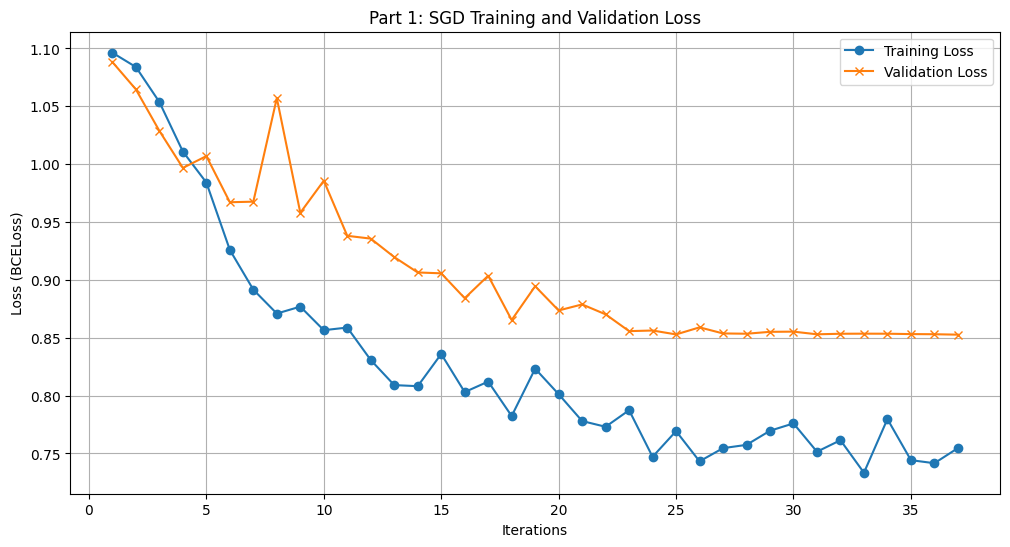

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(epochs, tr_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='x')
plt.title('Part 1: SGD Training and Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss (BCELoss)')
plt.legend()
plt.grid(True)
plt.show()
